In [12]:

# Step 0: imports and configuration
import sys
sys.path.insert(0, '/home1/jek/custom_pkg')
from tool.ty_pkg import tc_finder, latlon_extent

import subprocess, shutil
import xarray as xr
import numpy as np
import tempfile
from pathlib import Path
import dask.array as da
from datetime import datetime, timedelta
from joblib import Parallel, delayed
from scipy.ndimage import minimum_filter, maximum_filter, label

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
from matplotlib.collections import LineCollection

import cartopy.crs as ccrs
import cartopy.feature as cfeature

from sklearn.decomposition import PCA
import pickle

G = 9.80665  # 표준 중력 가속도
MAX_MEMBERS = 50
DATETIME = "2022082700"

# ─── tc_finder parameters (identical to reference notebook) ───
init_size        = 3        # degrees, search window around seed position
mask_size        = 4        # degrees, search radius for subsequent timesteps
mslp_z_dis       = 300      # km, max distance between MSLP min and Z300-Z500 max
mslp_z_dis_td    = 300      # km, TD-specific distance threshold
wind_thres       = 5        # m/s, minimum wind speed
vort_thres       = 5e-05    # s^-1, minimum vorticity
wind_vort_field  = 300      # km, radius for wind/vort field check
local_min_size   = 5        # degrees, window size for local minimum
patience         = 2        # timesteps, patience if TC not found
retro_opt        = 'td'     # retrograde option: strong systems only
start_track_time = 24       # hours, forward tracking starts at T+24h

# ─── Predict interval list: 12h, 24h, ..., 120h ───
predict_interval_list = np.arange(6, 121, 6)   # [12, 24, ..., 120]

T0 = datetime(2022, 8, 27, 0, 0)

# ─── IBTrACS best-track data (Hinnamnor 2022) ───
_bt = xr.open_dataset('/home1/jek/Pangu-Weather/input_data/IBTrACS.WP.v04r01.nc')
_bt_tc = _bt.where(_bt['season'] == 2022, drop=True)
_bt_tc['name_str'] = _bt_tc['name'].str.decode('utf-8').str.strip()
_bt_tc = _bt_tc.where(_bt_tc['name_str'].str.upper() == 'HINNAMNOR', drop=True)
storm_lat  = _bt_tc['usa_lat'][0].values.astype(np.float32)
storm_lon  = _bt_tc['usa_lon'][0].values.astype(np.float32)
storm_mslp = _bt_tc['usa_pres'][0].values.astype(np.float32)
storm_time = _bt_tc['iso_time'][0].values.astype('datetime64').astype(datetime)
_bt.close()

# fix negative longitudes
storm_lon = np.where(storm_lon < 0, storm_lon + 360, storm_lon)

_idx_mask = ~np.isnan(storm_lon)
storm_lat, storm_lon, storm_mslp, storm_time = (
    storm_lat[_idx_mask], storm_lon[_idx_mask],
    storm_mslp[_idx_mask], storm_time[_idx_mask]
)

# ─── Domain (same as reference notebook for Hinnamnor 2022-08-27) ───
lat_indices, lat_start, lat_end, lon_indices, lon_start, lon_end, extent, latlon_ratio = \
    latlon_extent(100, 160, 5, 45)
lon_grid, lat_grid = np.meshgrid(
    lon_indices[lon_start:lon_end + 1],
    lat_indices[lat_start:lat_end + 1]
)
print(f"Domain: lon {lon_indices[lon_start]:.2f}–{lon_indices[lon_end]:.2f}, "
      f"lat {lat_indices[lat_start]:.2f}–{lat_indices[lat_end]:.2f}")
print(f"Grid shape: {lat_grid.shape}")
print(f"Best-track entries loaded: {len(storm_time)}")
print(f"T+0h best-track position: lat={storm_lat[storm_time==T0][0]:.2f}, "
      f"lon={storm_lon[storm_time==T0][0]:.2f}")


Domain: lon 100.00–160.00, lat 45.00–5.00
Grid shape: (161, 241)
Best-track entries loaded: 85
T+0h best-track position: lat=21.70, lon=150.10


In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# tc_finder data wrapper — reads TIGGE xarray Dataset slices
# ─────────────────────────────────────────────────────────────────────────────
# TIGGE grid: latitude 90→-90 (descending), longitude 0→359.75
# tc_finder / latlon_extent uses lat: high→low (descending) — no flip needed


def _extract_domain(data_2d, ds_lat, ds_lon,
                    lat_indices, lon_indices,
                    lat_start, lat_end, lon_start, lon_end):
    """
    Slice a 2D (lat, lon) numpy array to the tc_finder domain.

    TIGGE latitude is already descending (90→-90), matching lat_indices
    from latlon_extent. No axis flip required.

    Parameters
    ----------
    data_2d : np.ndarray  shape (n_lat, n_lon)
    ds_lat   : 1-D array of TIGGE latitude values (descending, 90→-90)
    ds_lon   : 1-D array of TIGGE longitude values (0→359.75)

    Returns
    -------
    2-D array with shape matching lat_grid / lon_grid
    """
    target_lat = lat_indices[lat_start:lat_end + 1]   # descending (high→low)
    target_lon = lon_indices[lon_start:lon_end + 1]    # ascending

    lat_hi, lat_lo = target_lat[0], target_lat[-1]     # e.g. 45, 5
    lat_mask = (ds_lat >= lat_lo - 0.01) & (ds_lat <= lat_hi + 0.01)
    lat_i0 = np.where(lat_mask)[0][0]
    lat_i1 = np.where(lat_mask)[0][-1] + 1

    lon_hi, lon_lo = target_lon[-1], target_lon[0]     # e.g. 160, 100
    lon_mask = (ds_lon >= lon_lo - 0.01) & (ds_lon <= lon_hi + 0.01)
    lon_i0 = np.where(lon_mask)[0][0]
    lon_i1 = np.where(lon_mask)[0][-1] + 1

    return data_2d[lat_i0:lat_i1, lon_i0:lon_i1]


def get_tc_fields(ds_z, ds_u, ds_v, step_idx,
                  ds_lat, ds_lon,
                  lat_indices, lon_indices,
                  lat_start, lat_end, lon_start, lon_end):
    """
    Extract tc_finder inputs from a single-member, single-time TIGGE slice.

    Parameters
    ----------
    ds_z     : xr.Dataset  (dims: step, level, latitude, longitude — member already selected)
    ds_u     : xr.Dataset  (dims: step, level, latitude, longitude — member already selected)
    ds_v     : xr.Dataset  (dims: step, level, latitude, longitude — member already selected)
    step_idx : int   index into step dim  (T+0h→0, T+6h→1, T+24h→4, ...)

    Returns
    -------
    Z850     : 2-D array (gpm)   — primary field for tc_finder
    z_diff   : 2-D array (gpm)   — Z300 − Z500  (warm-core proxy)
    wind_spd : 2-D array (m/s)   — 1000 hPa wind speed (surface proxy)
    vort_850 : 2-D array (s⁻¹)  — 850 hPa relative vorticity
    """
    def get_level_2d(ds, varname, lev_hpa):
        arr = ds[varname].isel(step=step_idx).sel(level=lev_hpa).values
        return _extract_domain(arr, ds_lat, ds_lon,
                               lat_indices, lon_indices,
                               lat_start, lat_end, lon_start, lon_end)

    # Z850 in gpm
    Z850  = get_level_2d(ds_z, 'gh', 850)

    # z_diff = Z300 − Z500 (gpm) — warm-core thickness proxy
    Z300  = get_level_2d(ds_z, 'gh', 300)
    Z500  = get_level_2d(ds_z, 'gh', 500)
    z_diff = Z300 - Z500

    # 1000 hPa wind as surface proxy (m/s)
    u1000 = get_level_2d(ds_u, 'u', 1000)
    v1000 = get_level_2d(ds_v, 'v', 1000)
    wind_spd = np.sqrt(u1000**2 + v1000**2)

    # 850 hPa relative vorticity (s⁻¹) — finite-difference on lat/lon grid
    u850 = get_level_2d(ds_u, 'u', 850)
    v850 = get_level_2d(ds_v, 'v', 850)

    deg2rad = np.pi / 180.0
    R = 6371e3  # m
    delta_lon = 0.25 * deg2rad * R * np.cos(lat_grid * deg2rad)
    delta_lat = 0.25 * deg2rad * R

    dv_dx    =  np.gradient(v850, axis=1) / delta_lon
    du_dy    = -np.gradient(u850, axis=0) / delta_lat   # negative: lat descending
    vort_850 = dv_dx - du_dy

    return Z850, z_diff, wind_spd, vort_850


print("Data wrapper functions defined.")

Data wrapper functions defined.


In [14]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# ds = xr.open_dataset("/data09/TC/TIGGE/ENS_field_data/ecmf_pf_tquv.nc")
ds_z = xr.open_dataset("/data09/TC/TIGGE/ENS_field_data/ecmf_pf_z.nc")
ds_t = xr.open_dataset("/data09/TC/TIGGE/ENS_field_data/ecmf_pf_t.nc")
ds_q = xr.open_dataset("/data09/TC/TIGGE/ENS_field_data/ecmf_pf_q.nc")
ds_u = xr.open_dataset("/data09/TC/TIGGE/ENS_field_data/ecmf_pf_u.nc")
ds_v = xr.open_dataset("/data09/TC/TIGGE/ENS_field_data/ecmf_pf_v.nc")

In [15]:
xr.open_dataset("/data09/TC/TIGGE/ENS_field_data/ecmf_cf_z.nc")

<xarray.Dataset> Size: 6GB
Dimensions:    (longitude: 1440, latitude: 721, level: 9, step: 41, date: 2)
Coordinates:
  * longitude  (longitude) float32 6kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
  * latitude   (latitude) float32 3kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * level      (level) int32 36B 50 200 250 300 500 700 850 925 1000
  * step       (step) timedelta64[ns] 328B 0 days 00:00:00 ... 10 days 00:00:00
  * date       (date) datetime64[ns] 16B 2022-08-27 2022-08-28
Data variables:
    gh         (date, step, level, latitude, longitude) float64 6GB ...
Attributes:
    Conventions:  CF-1.6
    history:      2025-10-02 12:17:20 GMT by grib_to_netcdf-2.26.0: grib_to_n...

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# tc_finder tracking — forward + retrograde, per ensemble member
# ─────────────────────────────────────────────────────────────────────────────

# TIGGE file paths (PF: perturbed forecast, 50 members)
Z_PATH    = "/data09/TC/TIGGE/ENS_field_data/ecmf_pf_z.nc"
U_PATH    = "/data09/TC/TIGGE/ENS_field_data/ecmf_pf_u.nc"
V_PATH    = "/data09/TC/TIGGE/ENS_field_data/ecmf_pf_v.nc"

# CF file paths (control forecast, 1 deterministic run — step is timedelta, has date dim)
CF_Z_PATH  = "/data09/TC/TIGGE/ENS_field_data/ecmf_cf_z.nc"
CF_UV_PATH = "/data09/TC/TIGGE/ENS_field_data/ecmf_cf_tquv.nc"   # u, v inside

CF_MEMBER_ID = 50  # 0-indexed; CF is the 51st member

# ─── ssv_dict save/load ───────────────────────────────────────────────────────
new_ssv = 'n'   # 'y' = compute fresh; 'n' = load from file
SSV_PKL = f"/data09/TC/TIGGE/ENS_field_data/ECMWF_Track_{T0.strftime('%Y%m%d%H')}.pkl"
# ─────────────────────────────────────────────────────────────────────────────


def _select_member(ds_z_full, ds_u_full, ds_v_full, member_id, T0):
    """
    Return (ds_zm, ds_um, ds_vm, ds_lat, ds_lon) for a given member.

    For PF (member_id 0–49): selects by number coord (1-indexed).
    For CF (member_id == CF_MEMBER_ID): selects by date (T0's date), no number dim.
    ds_u_full / ds_v_full for CF may be the same tquv file.
    """
    ds_lat = ds_z_full['latitude'].values   # descending (90→-90)
    ds_lon = ds_z_full['longitude'].values  # ascending  (0→359.75)
    if member_id == CF_MEMBER_ID:
        date_sel = np.datetime64(T0.date())
        ds_zm = ds_z_full.sel(date=date_sel)
        ds_um = ds_u_full.sel(date=date_sel)
        ds_vm = ds_v_full.sel(date=date_sel)
    else:
        member_num = member_id + 1   # TIGGE number is 1-indexed
        ds_zm = ds_z_full.sel(number=member_num)
        ds_um = ds_u_full.sel(number=member_num)
        ds_vm = ds_v_full.sel(number=member_num)
    return ds_zm, ds_um, ds_vm, ds_lat, ds_lon


def process_single_member(member_id,
                           z_path, u_path, v_path,
                           predict_interval_list, start_track_time,
                           lat_indices, lon_indices,
                           lat_start, lat_end, lon_start, lon_end,
                           lat_grid, lon_grid,
                           storm_lon, storm_lat, storm_mslp, storm_time,
                           T0, retro_opt,
                           init_size, mask_size, local_min_size,
                           mslp_z_dis, mslp_z_dis_td,
                           wind_thres, vort_thres, wind_vort_field, patience):
    """
    Run tc_finder forward + retrograde tracking for one ensemble member.

    member_id 0–49: PF member (number = member_id + 1)
    member_id  50 : CF (control forecast, no number dim, uses date dim)
    """
    ens_min_position = {}
    current_patience = 0

    with xr.open_dataset(z_path) as ds_z_full, \
         xr.open_dataset(u_path) as ds_u_full, \
         xr.open_dataset(v_path) as ds_v_full:

        ds_zm, ds_um, ds_vm, ds_lat, ds_lon = _select_member(
            ds_z_full, ds_u_full, ds_v_full, member_id, T0)

        # ── 1. Forward tracking: start_track_time → end ──────────────────
        for predict_interval in predict_interval_list:
            if predict_interval < start_track_time:
                continue
            pred_time = T0 + timedelta(hours=int(predict_interval))
            step_idx  = int(predict_interval // 6)   # T+0→0, T+6→1, T+24→4, ...

            Z850, z_diff, wind_spd, vort_850 = get_tc_fields(
                ds_zm, ds_um, ds_vm, step_idx,
                ds_lat, ds_lon,
                lat_indices, lon_indices,
                lat_start, lat_end, lon_start, lon_end
            )

            ens_min_position, current_patience = tc_finder(
                Z850, lat_indices, lon_indices,
                lat_start, lon_start, lat_grid, lon_grid,
                z_diff, wind_spd, vort_850,
                pred_time, storm_lon, storm_lat, storm_mslp, storm_time,
                T0, ens_min_position, current_patience,
                mask_size=mask_size, init_size=init_size,
                local_min_size=local_min_size,
                mslp_z_dis=mslp_z_dis,
                wind_thres=wind_thres, vort_thres=vort_thres,
                wind_vort_field=wind_vort_field, patience=patience
            )

        # ── 2. Retrograde tracking: end → start ──────────────────────────
        if retro_opt == 'td':
            for predict_interval in predict_interval_list[::-1]:
                pred_time = T0 + timedelta(hours=int(predict_interval))
                step_idx  = int(predict_interval // 6)

                Z850, z_diff, wind_spd, vort_850 = get_tc_fields(
                    ds_zm, ds_um, ds_vm, step_idx,
                    ds_lat, ds_lon,
                    lat_indices, lon_indices,
                    lat_start, lat_end, lon_start, lon_end
                )

                ens_min_position, current_patience = tc_finder(
                    Z850, lat_indices, lon_indices,
                    lat_start, lon_start, lat_grid, lon_grid,
                    z_diff, wind_spd, vort_850,
                    pred_time, storm_lon, storm_lat, storm_mslp, storm_time,
                    T0, ens_min_position, current_patience,
                    mask_size=mask_size, local_min_size=local_min_size,
                    back_prop='y', mslp_z_dis=mslp_z_dis_td,
                    wind_thres=wind_thres, vort_thres=vort_thres,
                    wind_vort_field=wind_vort_field, patience=patience
                )

    return member_id, {k: ens_min_position[k] for k in sorted(ens_min_position)}


# ── Member list: 50 PF + 1 CF = 51 total ─────────────────────────────────────
pf_member_ids = list(range(50))    # 0–49 → PF number 1–50
all_member_ids = pf_member_ids + [CF_MEMBER_ID]
print(f"Total members to process: {len(all_member_ids)}  (PF={len(pf_member_ids)}, CF=1)")


if new_ssv == 'y':
    # ── PF: Parallel tc_finder tracking ──────────────────────────────────────
    pf_results = Parallel(n_jobs=20, verbose=5)(
        delayed(process_single_member)(
            member_id,
            Z_PATH, U_PATH, V_PATH,
            predict_interval_list, start_track_time,
            lat_indices, lon_indices,
            lat_start, lat_end, lon_start, lon_end,
            lat_grid, lon_grid,
            storm_lon, storm_lat, storm_mslp, storm_time,
            T0, retro_opt,
            init_size, mask_size, local_min_size,
            mslp_z_dis, mslp_z_dis_td,
            wind_thres, vort_thres, wind_vort_field, patience
        )
        for member_id in pf_member_ids
    )

    # ── CF: single member tracking ────────────────────────────────────────────
    cf_result = process_single_member(
        CF_MEMBER_ID,
        CF_Z_PATH, CF_UV_PATH, CF_UV_PATH,   # u and v both in tquv file
        predict_interval_list, start_track_time,
        lat_indices, lon_indices,
        lat_start, lat_end, lon_start, lon_end,
        lat_grid, lon_grid,
        storm_lon, storm_lat, storm_mslp, storm_time,
        T0, retro_opt,
        init_size, mask_size, local_min_size,
        mslp_z_dis, mslp_z_dis_td,
        wind_thres, vort_thres, wind_vort_field, patience
    )

    # ── Aggregate: ssv_dict[T0][member_id] = {datetime: {lon,lat,mslp,type}} ─
    all_results = pf_results + [cf_result]
    ssv_dict = {T0: {mid: pos for mid, pos in all_results}}
    print(f"Tracking complete.  Members with at least one fix: "
          f"{sum(1 for _, pos in all_results if pos)}/{len(all_results)}")

    with open(SSV_PKL, 'wb') as f:
        pickle.dump(ssv_dict, f)
    print(f"Saved ssv_dict to {SSV_PKL}")

else:
    with open(SSV_PKL, 'rb') as f:
        ssv_dict = pickle.load(f)
    print(f"Loaded ssv_dict from {SSV_PKL}")

N_ENS = len(ssv_dict[T0])
print(f"ssv_dict: {N_ENS} members")

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# TC-Removed Steering Wind Computation
# ─────────────────────────────────────────────────────────────────────────────
from tool.ty_pkg import WindFieldSolver, get_factorized_solver

# ── Parameters ────────────────────────────────────────────────────────────────
TARGET_HOUR    = 72                           # ESA target forecast hour
STEER_LEVELS   = [850, 700, 500, 300, 250]   # hPa (600/400 not in TIGGE)
STEER_DP       = np.array([100., 125., 100., 75., 50.])   # layer thickness weights (sum=450)
ANALYSIS_HOURS = [0, 12, 24, 48]             # analysis times for ESA

# Pre-factorize Poisson solver on the tc_finder domain grid (0.25° resolution)
_poisson_solver = get_factorized_solver(lat_grid, dx=111e3/4, dy=111e3/4)

# Grid spacing for vorticity/divergence computation on domain (lat descending)
_deg2rad  = np.pi / 180.0
_R        = 6371e3
_delta_lon = 0.25 * _deg2rad * _R * np.cos(lat_grid * _deg2rad)  # (n_lat, n_lon)
_delta_lat = 0.25 * _deg2rad * _R

# Output arrays: shape (N_ENS, n_lat, n_lon) for each analysis hour
_grid_shape = lat_grid.shape
u_steer = {h: np.full((51, *_grid_shape), np.nan) for h in ANALYSIS_HOURS}
v_steer = {h: np.full((51, *_grid_shape), np.nan) for h in ANALYSIS_HOURS}


def _compute_steer_for_member(member_id, analysis_hour):
    """
    Compute TC-removed steering wind for one member at one analysis time.
    Returns (u_layer_avg, v_layer_avg) arrays on the tc_finder domain.
    """
    step_idx  = analysis_hour // 6
    pred_time = T0 + timedelta(hours=analysis_hour)

    # Get TC center position
    if analysis_hour == 0:
        # Use IBTrACS best-track at T0
        _t0_np = np.datetime64(T0)
        _idx   = np.where(np.array(list(storm_time)) == _t0_np)[0]
        if len(_idx) == 0:
            return None, None
        center_lat = float(storm_lat[_idx[0]])
        center_lon = float(storm_lon[_idx[0]])
    else:
        member_ssv = ssv_dict[T0].get(member_id, {})
        if pred_time not in member_ssv:
            return None, None
        center_lat = float(member_ssv[pred_time]['lat'])
        center_lon = float(member_ssv[pred_time]['lon'])

    # Load wind data
    is_cf = (member_id == CF_MEMBER_ID)
    u_path = CF_UV_PATH if is_cf else U_PATH
    v_path = CF_UV_PATH if is_cf else V_PATH

    with xr.open_dataset(u_path) as ds_u_full, \
         xr.open_dataset(v_path) as ds_v_full:

        ds_lat = ds_u_full['latitude'].values
        ds_lon = ds_u_full['longitude'].values

        if is_cf:
            date_sel = np.datetime64(T0.date())
            ds_um = ds_u_full.sel(date=date_sel)
            ds_vm = ds_v_full.sel(date=date_sel)
        else:
            member_num = member_id + 1
            ds_um = ds_u_full.sel(number=member_num)
            ds_vm = ds_v_full.sel(number=member_num)

        u_layers = []
        v_layers = []

        for lev in STEER_LEVELS:
            u_arr = ds_um['u'].isel(step=step_idx).sel(level=lev).values
            v_arr = ds_vm['v'].isel(step=step_idx).sel(level=lev).values

            u_dom = _extract_domain(u_arr, ds_lat, ds_lon,
                                    lat_indices, lon_indices,
                                    lat_start, lat_end, lon_start, lon_end)
            v_dom = _extract_domain(v_arr, ds_lat, ds_lon,
                                    lat_indices, lon_indices,
                                    lat_start, lat_end, lon_start, lon_end)

            # Vorticity and divergence on descending-lat grid
            dv_dx  =  np.gradient(v_dom, axis=1) / _delta_lon
            du_dy  = -np.gradient(u_dom, axis=0) / _delta_lat   # neg: lat descending
            du_dx  =  np.gradient(u_dom, axis=1) / _delta_lon
            dv_dy  = -np.gradient(v_dom, axis=0) / _delta_lat

            vort = dv_dx - du_dy
            div  = du_dx + dv_dy

            # Poisson inversion → TC circulation (u_ty, v_ty)
            solver = WindFieldSolver(
                lat_grid, lon_grid,
                center_lat, center_lon,
                vort, div,
                max_iter=50000, tol=1e-2,
                sparse_solver=_poisson_solver
            )
            u_ty, v_ty = solver.solve()

            u_layers.append(u_dom - u_ty)   # TC-removed
            v_layers.append(v_dom - v_ty)

    # Pressure-weighted layer average
    dp_sum = STEER_DP.sum()
    u_avg = sum(dp * u for dp, u in zip(STEER_DP, u_layers)) / dp_sum
    v_avg = sum(dp * v for dp, v in zip(STEER_DP, v_layers)) / dp_sum
    return u_avg, v_avg


# ── Compute for all members and analysis hours ────────────────────────────────
STEER_PKL = f"/data09/TC/TIGGE/ENS_field_data/ECMWF_Steer_{T0.strftime('%Y%m%d%H')}.pkl"
new_steer = 'n'   # 'y' = recompute; 'n' = load

if new_steer == 'y':
    for member_id in range(51):
        for h in ANALYSIS_HOURS:
            u_avg, v_avg = _compute_steer_for_member(member_id, h)
            if u_avg is not None:
                u_steer[h][member_id] = u_avg
                v_steer[h][member_id] = v_avg
        if member_id % 10 == 0:
            print(f"  member {member_id}/51 done")
    with open(STEER_PKL, 'wb') as f:
        pickle.dump({'u_steer': u_steer, 'v_steer': v_steer}, f)
    print(f"Saved steering wind to {STEER_PKL}")
else:
    _d = pickle.load(open(STEER_PKL, 'rb'))
    u_steer = _d['u_steer']
    v_steer = _d['v_steer']
    print(f"Loaded steering wind from {STEER_PKL}")

print("Steering wind computation complete.")

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# ESA — Ensemble Sensitivity Analysis
# ─────────────────────────────────────────────────────────────────────────────

# ── Step 1: Get TARGET_HOUR TC positions for all members ──────────────────────
pred_time_target = T0 + timedelta(hours=TARGET_HOUR)

mems_tar, lats_tar, lons_tar = [], [], []
for member_id in range(51):
    member_ssv = ssv_dict[T0].get(member_id, {})
    if pred_time_target in member_ssv:
        info = member_ssv[pred_time_target]
        mems_tar.append(member_id)
        lats_tar.append(float(info['lat']))
        lons_tar.append(float(info['lon']))

mems_tar = np.array(mems_tar)
lats_tar = np.array(lats_tar)
lons_tar = np.array(lons_tar)
N_tar    = len(mems_tar)
print(f"Members with T+{TARGET_HOUR}h fix: {N_tar}/51")

# ── Step 2: PCA on target positions (cosine-corrected distance, km) ───────────
mean_lat  = lats_tar.mean()
mean_lon  = lons_tar.mean()
cos_lat   = np.cos(np.radians(mean_lat))

tar_pos = np.stack([(lons_tar - mean_lon) * cos_lat,
                     lats_tar - mean_lat], axis=1)

pca_tar   = PCA(n_components=1)
d_tar     = pca_tar.fit_transform(tar_pos).ravel() * 111.0   # degrees → km
d_anom    = d_tar - d_tar.mean()

# Sort members: bottom (SW/small) → top (NE/large)
sort_idx  = np.argsort(d_tar)
mems_sort = mems_tar[sort_idx]

group_num   = 10
top10_ids   = mems_sort[-group_num:]   # NE group: largest PCA projection
bot10_ids   = mems_sort[:group_num]    # SW group: smallest PCA projection

pca_axis = pca_tar.components_[0]   # unit vector of spread axis
print(f"PCA axis (lon, lat): ({pca_axis[0]:.3f}, {pca_axis[1]:.3f})")
print(f"Track spread: {d_tar.min():.1f} to {d_tar.max():.1f} km")
print(f"Top-10 member IDs: {top10_ids}")
print(f"Bot-10 member IDs: {bot10_ids}")

# ── Step 3: Covariance maps (ESA) ─────────────────────────────────────────────
cov_u, cov_v = {}, {}

for h in ANALYSIS_HOURS:
    # Filter to members that have both tracking AND steering wind at this hour
    u_ens = u_steer[h][mems_tar]   # (N_tar, n_lat, n_lon)
    v_ens = v_steer[h][mems_tar]

    valid_mask = ~np.any(np.isnan(u_ens.reshape(N_tar, -1)), axis=1)
    n_valid    = valid_mask.sum()
    if n_valid < 5:
        print(f"T+{h}h: only {n_valid} valid members — skipping ESA")
        cov_u[h] = np.full(_grid_shape, np.nan)
        cov_v[h] = np.full(_grid_shape, np.nan)
        continue

    d_valid  = d_anom[valid_mask]
    u_flat   = u_ens[valid_mask].reshape(n_valid, -1)   # (n_valid, n_pts)
    v_flat   = v_ens[valid_mask].reshape(n_valid, -1)

    # Normalise predictor fields (zero mean, unit std)
    u_mean, u_std = u_flat.mean(axis=0), u_flat.std(axis=0)
    v_mean, v_std = v_flat.mean(axis=0), v_flat.std(axis=0)
    u_std[u_std < 1e-10] = 1.0
    v_std[v_std < 1e-10] = 1.0
    u_norm = (u_flat - u_mean) / u_std
    v_norm = (v_flat - v_mean) / v_std

    # Grid-point covariance: cov = (d_anom ⊙ x_norm) / N
    cov_u[h] = ((d_valid @ u_norm) / n_valid).reshape(_grid_shape)
    cov_v[h] = ((d_valid @ v_norm) / n_valid).reshape(_grid_shape)
    print(f"T+{h}h ESA complete  (N={n_valid})")

print("ESA complete.")

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# ESA Sensitivity Plot  (2×2 panel: T+0/12/24/48h)
# ─────────────────────────────────────────────────────────────────────────────
PLOT_LON = (120, 160)
PLOT_LAT  = (15, 45)

# Domain lon/lat for plotting
_plot_lon_arr = lon_indices[lon_start:lon_end + 1]
_plot_lat_arr = lat_indices[lat_start:lat_end + 1]   # descending

# Quiver stride (reduce arrow density)
_qs = 4   # every 4th grid point

fig, axes = plt.subplots(2, 2, figsize=(14, 10),
                          subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

# Jet colormap for member track time
_cmap_track = plt.cm.jet
_norm_track  = mcolors.Normalize(vmin=0, vmax=120)

for i, h in enumerate(ANALYSIS_HOURS):
    ax = axes[i]
    ax.set_extent([*PLOT_LON, *PLOT_LAT], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS,   linewidth=0.3, linestyle=':')
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.5)
    gl.top_labels = gl.right_labels = False

    # ── Background: ensemble mean steering wind (streamlines) ────────────────
    u_mean_h = np.nanmean(u_steer[h], axis=0)
    v_mean_h = np.nanmean(v_steer[h], axis=0)
    ax.streamplot(_plot_lon_arr, _plot_lat_arr[::-1],
                  u_mean_h[::-1, :], v_mean_h[::-1, :],
                  color='k', linewidth=0.6, density=1.0,
                  transform=ccrs.PlateCarree())

    # ── ESA sensitivity: covariance quiver (blue) ────────────────────────────
    if not np.all(np.isnan(cov_u[h])):
        Q = ax.quiver(
            _plot_lon_arr[::_qs], _plot_lat_arr[::_qs],
            cov_u[h][::_qs, ::_qs], cov_v[h][::_qs, ::_qs],
            color='royalblue', scale=50, width=0.003,
            transform=ccrs.PlateCarree()
        )
        ax.quiverkey(Q, 0.88, 0.06, 10, '10 m/s', labelpos='E',
                     coordinates='axes', fontproperties={'size': 8})

    # ── TC tracks (all tracked members, jet colormap) ─────────────────────────
    for member_id in ssv_dict[T0]:
        ssv_m = ssv_dict[T0][member_id]
        if not ssv_m:
            continue
        times_m = sorted(ssv_m.keys())
        lons_m  = [ssv_m[t]['lon'] for t in times_m]
        lats_m  = [ssv_m[t]['lat'] for t in times_m]
        hours_m = [(t - T0).total_seconds() / 3600 for t in times_m]
        sc = ax.scatter(lons_m, lats_m, c=hours_m, cmap=_cmap_track,
                        norm=_norm_track, s=2, alpha=0.4,
                        transform=ccrs.PlateCarree(), zorder=3)

    # ── Target positions: top10 (red) / bot10 (blue) ─────────────────────────
    ax.scatter(lons_tar[np.isin(mems_tar, top10_ids)],
               lats_tar[np.isin(mems_tar, top10_ids)],
               color='red',  s=25, marker='o', zorder=5,
               transform=ccrs.PlateCarree(), label='Top-10')
    ax.scatter(lons_tar[np.isin(mems_tar, bot10_ids)],
               lats_tar[np.isin(mems_tar, bot10_ids)],
               color='blue', s=25, marker='o', zorder=5,
               transform=ccrs.PlateCarree(), label='Bot-10')

    # ── PCA axis arrow at ensemble mean target position ───────────────────────
    spread_km = (d_tar.max() - d_tar.min()) / 2
    arrow_len  = spread_km / 111.0 * 0.4   # scale arrow to ~40% of spread range
    ax.annotate('', xy=(mean_lon + pca_axis[0] * arrow_len / cos_lat,
                         mean_lat + pca_axis[1] * arrow_len),
                    xytext=(mean_lon, mean_lat),
                    arrowprops=dict(arrowstyle='->', color='red', lw=2.0),
                    transform=ccrs.PlateCarree())

    # ── Best-track at T0 ──────────────────────────────────────────────────────
    _t0_idx = np.where(storm_time == T0)[0]
    if len(_t0_idx):
        ax.plot(storm_lon[_t0_idx[0]], storm_lat[_t0_idx[0]],
                'k*', ms=12, transform=ccrs.PlateCarree(), zorder=6)

    ax.set_title(f'T+{h}h Steering Wind ESA  (target: T+{TARGET_HOUR}h)',
                 fontsize=10)
    if i == 0:
        ax.legend(loc='upper left', fontsize=7, markerscale=1.5)

plt.colorbar(plt.cm.ScalarMappable(norm=_norm_track, cmap=_cmap_track),
             ax=axes, label='Forecast hour', fraction=0.02, pad=0.04)
plt.suptitle(f'ECMWF TIGGE  |  Init: {T0:%Y-%m-%d %H}Z  |  Target: T+{TARGET_HOUR}h',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(f'/data09/TC/TIGGE/ENS_field_data/ESA_sensitivity_{T0:%Y%m%d%H}_T{TARGET_HOUR}.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("ESA sensitivity plot saved.")

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Top-10 / Bottom-10  Cross-Section PV + Wind
# Reference: Track_Steer_ESA.ipynb (same cross-section geometry)
# ─────────────────────────────────────────────────────────────────────────────
import metpy.calc as mpcalc
from metpy.units import units as munits
from metpy.interpolate import cross_section

# ── Cross-section configuration (identical to Track_Steer_ESA) ───────────────
XS_START = (15., 155.)   # (lat, lon)  diagonal start
XS_END   = (40., 142.)   # (lat, lon)  diagonal end
LON_BAND = (147.5, 152.5)   # longitude band for vertical cross-section B

# Full pressure levels for PV computation
PV_LEVELS = [1000, 925, 850, 700, 600, 500, 400, 300, 250, 200, 150, 100]
# TIGGE available: [200, 250, 300, 500, 700, 850, 925, 1000] — subset
_TIGGE_LEVS = [1000, 925, 850, 700, 500, 300, 250, 200]

# Analysis time for cross-section (use TARGET_HOUR field)
XSEC_STEP_IDX = TARGET_HOUR // 6


def _build_xr_for_pv(member_ids_group, is_cf_group=False):
    """
    Return xr.Dataset with group-mean u, v, z fields on TIGGE pressure levels
    suitable for MetPy PV calculation.  Dimensions: (level, lat, lon).
    """
    u_sum = np.zeros((len(_TIGGE_LEVS), *_grid_shape))
    v_sum = np.zeros_like(u_sum)
    z_sum = np.zeros_like(u_sum)
    n = 0

    for mid in member_ids_group:
        is_cf = (mid == CF_MEMBER_ID)
        z_path = CF_Z_PATH  if is_cf else Z_PATH
        u_path = CF_UV_PATH if is_cf else U_PATH
        v_path = CF_UV_PATH if is_cf else V_PATH

        with xr.open_dataset(z_path) as ds_zf, \
             xr.open_dataset(u_path) as ds_uf, \
             xr.open_dataset(v_path) as ds_vf:

            ds_lat = ds_zf['latitude'].values
            ds_lon = ds_zf['longitude'].values

            ds_zm, ds_um, ds_vm, _, _ = _select_member(ds_zf, ds_uf, ds_vf, mid, T0)

            for k, lev in enumerate(_TIGGE_LEVS):
                z_arr = ds_zm['gh'].isel(step=XSEC_STEP_IDX).sel(level=lev).values
                u_arr = ds_um['u'].isel(step=XSEC_STEP_IDX).sel(level=lev).values
                v_arr = ds_vm['v'].isel(step=XSEC_STEP_IDX).sel(level=lev).values

                z_sum[k] += _extract_domain(z_arr, ds_lat, ds_lon,
                                             lat_indices, lon_indices,
                                             lat_start, lat_end, lon_start, lon_end)
                u_sum[k] += _extract_domain(u_arr, ds_lat, ds_lon,
                                             lat_indices, lon_indices,
                                             lat_start, lat_end, lon_start, lon_end)
                v_sum[k] += _extract_domain(v_arr, ds_lat, ds_lon,
                                             lat_indices, lon_indices,
                                             lat_start, lat_end, lon_start, lon_end)
        n += 1

    u_mean = u_sum / n
    v_mean = v_sum / n
    z_mean = z_sum / n  # geopotential height (gpm)

    # Build xr.Dataset (lat ascending for MetPy)
    _lats = _plot_lat_arr[::-1]   # ascending
    _lons = _plot_lon_arr
    _levs = np.array(_TIGGE_LEVS, dtype=np.float32)
    _p_Pa = _levs * 100.0         # hPa → Pa

    ds_out = xr.Dataset({
        'u':    (['level', 'lat', 'lon'], u_mean[:, ::-1, :],
                 {'units': 'm/s'}),
        'v':    (['level', 'lat', 'lon'], v_mean[:, ::-1, :],
                 {'units': 'm/s'}),
        'z':    (['level', 'lat', 'lon'], z_mean[:, ::-1, :],
                 {'units': 'm'}),
        'pressure': (['level'], _p_Pa, {'units': 'Pa'}),
    }, coords={
        'level': _levs,
        'lat':   _lats,
        'lon':   _lons,
    })
    return ds_out


# ── Build group-mean datasets ─────────────────────────────────────────────────
print("Building top-10 mean fields...")
ds_top = _build_xr_for_pv(top10_ids)
print("Building bot-10 mean fields...")
ds_bot = _build_xr_for_pv(bot10_ids)


def _compute_pv(ds):
    """Compute PV (PVU) and potential temperature θ (K) from group-mean xr.Dataset."""
    p_da     = ds['pressure'].values[:, None, None] * np.ones(ds['u'].shape)
    u_da     = ds['u'].values   * munits('m/s')
    v_da     = ds['v'].values   * munits('m/s')
    p_metpy  = p_da * munits('Pa')

    # Potential temperature: θ = T * (p0/p)^(R/cp)  — derive from z via hypsometric eq
    # Approximation: use z to estimate T via lapse rate, or directly compute θ from z
    # Here we use standard atmosphere lapse rate as proxy: Tv ≈ z gradient
    # For a more accurate approach, ds_t (temperature) should be loaded; but
    # since ds_t was loaded at session start we use a simplified θ from the
    # geopotential height via: T ≈ -dZ/dlnp * g/R  (hypsometric)
    lnp = np.log(ds['pressure'].values)
    dZ_dlnp = np.gradient(ds['z'].values, lnp, axis=0)  # (level, lat, lon)
    T_approx = -dZ_dlnp * G / 287.05  # J/(kg·K) / (m/s²) / R = K
    p0 = 100000.0  # Pa
    theta = T_approx * (p0 / ds['pressure'].values[:, None, None]) ** (287.05 / 1004.0)

    theta_da = theta * munits('K')
    pv = mpcalc.potential_vorticity_baroclinic(
        theta_da, p_metpy, u_da, v_da,
        latitude=ds['lat'].values * munits('degrees')
    )
    pv_pvu = (pv * 1e6).magnitude   # convert to PVU
    return pv_pvu, theta


pv_top, theta_top = _compute_pv(ds_top)
pv_bot, theta_bot = _compute_pv(ds_bot)
print("PV computed for both groups.")


# ── Plot: 2 panels (diagonal cross-section A + longitude band B) ──────────────
_lats_asc = _plot_lat_arr[::-1]
_lons_asc  = _plot_lon_arr
_levs_arr  = np.array(_TIGGE_LEVS, dtype=float)

fig, axes_xs = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for ax, label, pv_top_xs, pv_bot_xs, theta_top_xs, theta_bot_xs in [
    (axes_xs[0], 'A: Diagonal (15°N,155°E → 40°N,142°E)', None, None, None, None),
    (axes_xs[1], 'B: Lon-band 147.5–152.5°E', None, None, None, None),
]:
    pass   # placeholder — computed below

# Cross-section A: diagonal using MetPy
_ds_top_metpy = ds_top.rename({'lat': 'latitude', 'lon': 'longitude'})
_ds_bot_metpy = ds_bot.rename({'lat': 'latitude', 'lon': 'longitude'})

# Add PV and theta to datasets for cross_section interpolation
for _ds, _pv, _theta in [
    (_ds_top_metpy, pv_top, theta_top),
    (_ds_bot_metpy, pv_bot, theta_bot),
]:
    _ds['pv']    = xr.DataArray(_pv,    dims=['level', 'latitude', 'longitude'])
    _ds['theta'] = xr.DataArray(_theta, dims=['level', 'latitude', 'longitude'])
    _ds = _ds.assign_coords({'latitude': _lats_asc, 'longitude': _lons_asc})

# ── Panel A: diagonal cross-section ──────────────────────────────────────────
_xs_top_A = cross_section(_ds_top_metpy, XS_START, XS_END)
_xs_bot_A = cross_section(_ds_bot_metpy, XS_START, XS_END)

ax = axes_xs[0]
_x_A = np.arange(_xs_top_A.sizes.get('index', _xs_top_A['latitude'].size))

# PV contours
clevs_pv = np.linspace(0, 3, 31)
cs_top = ax.contourf(_x_A, _levs_arr, _xs_top_A['pv'].values,
                     levels=clevs_pv, cmap='Reds', alpha=0.5)
cs_bot = ax.contourf(_x_A, _levs_arr, _xs_bot_A['pv'].values,
                     levels=clevs_pv, cmap='Blues', alpha=0.5)
ax.contour(_x_A, _levs_arr, _xs_top_A['pv'].values, levels=[1.5],
           colors='red',  linestyles='--', linewidths=1.5)
ax.contour(_x_A, _levs_arr, _xs_bot_A['pv'].values, levels=[1.5],
           colors='blue', linestyles='--', linewidths=1.5)

# θ isentropes (ensemble mean)
_theta_mean_A = (_xs_top_A['theta'].values + _xs_bot_A['theta'].values) / 2
ax.contour(_x_A, _levs_arr, _theta_mean_A,
           levels=np.arange(280, 401, 5), colors='gray', linewidths=0.5, alpha=0.7)

ax.set_ylim(1000, 100)
ax.set_ylabel('Pressure (hPa)')
ax.set_title('A: Diagonal (15°N,155°E → 40°N,142°E)')
plt.colorbar(cs_top, ax=ax, label='PV (Top-10, PVU)', fraction=0.04, pad=0.04)

# ── Panel B: longitude band cross-section ─────────────────────────────────────
_lon_mask = (_lons_asc >= LON_BAND[0]) & (_lons_asc <= LON_BAND[1])

pv_top_B    = pv_top[:, :, _lon_mask].mean(axis=2)      # (level, lat)
pv_bot_B    = pv_bot[:, :, _lon_mask].mean(axis=2)
theta_top_B = theta_top[:, :, _lon_mask].mean(axis=2)
theta_bot_B = theta_bot[:, :, _lon_mask].mean(axis=2)

ax = axes_xs[1]
cs_top2 = ax.contourf(_lats_asc, _levs_arr, pv_top_B,
                       levels=clevs_pv, cmap='Reds',  alpha=0.5)
cs_bot2 = ax.contourf(_lats_asc, _levs_arr, pv_bot_B,
                       levels=clevs_pv, cmap='Blues', alpha=0.5)
ax.contour(_lats_asc, _levs_arr, pv_top_B, levels=[1.5],
           colors='red',  linestyles='--', linewidths=1.5)
ax.contour(_lats_asc, _levs_arr, pv_bot_B, levels=[1.5],
           colors='blue', linestyles='--', linewidths=1.5)

_theta_mean_B = (theta_top_B + theta_bot_B) / 2
ax.contour(_lats_asc, _levs_arr, _theta_mean_B,
           levels=np.arange(280, 401, 5), colors='gray', linewidths=0.5, alpha=0.7)

ax.set_ylim(1000, 100)
ax.set_xlabel('Latitude (°N)')
ax.set_title(f'B: Lon-band {LON_BAND[0]}–{LON_BAND[1]}°E')
plt.colorbar(cs_top2, ax=ax, label='PV (Top-10, PVU)', fraction=0.04, pad=0.04)

from matplotlib.lines import Line2D
_legend = [
    Line2D([0], [0], color='red',  lw=2, label='Top-10 (NE group)'),
    Line2D([0], [0], color='blue', lw=2, label='Bot-10 (SW group)'),
    Line2D([0], [0], color='gray', lw=1, linestyle='-', label='θ isentrope'),
    Line2D([0], [0], color='black', lw=1.5, linestyle='--', label='1.5 PVU tropopause'),
]
axes_xs[0].legend(handles=_legend, loc='lower left', fontsize=8)

plt.suptitle(f'PV Cross-Section  |  T+{TARGET_HOUR}h  |  Top-10 (red) vs Bot-10 (blue)\n'
             f'Init: {T0:%Y-%m-%d %H}Z  (θ isentropes: 280–400 K, 5 K)',
             fontsize=11)
plt.tight_layout()
plt.savefig(f'/data09/TC/TIGGE/ENS_field_data/PV_xsec_{T0:%Y%m%d%H}_T{TARGET_HOUR}.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Cross-section PV plot saved.")

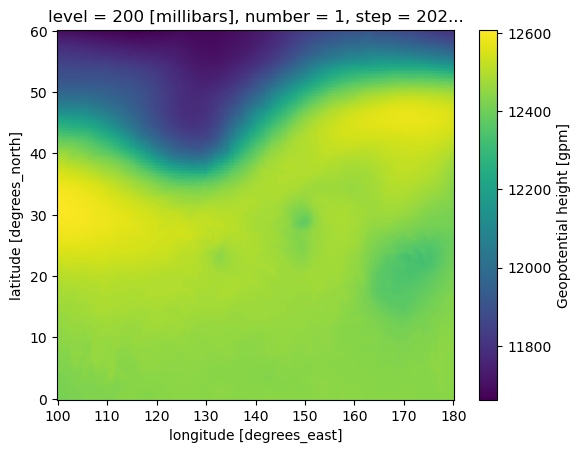

In [23]:
ds_z.sel(step = "2022-08-27T00:00:00", level = 200, longitude = slice(100, 180), latitude = slice(60, 0))['gh'].isel(number = 0).plot()

{6: 55.4, 12: 54.8, 18: 89.7, 24: 79.2, 30: 94.9, 36: 112.4, 42: 129.7, 48: 148.5, 54: 177.6, 60: 215.4, 66: 268.7, 72: 321.0, 78: 412.0, 84: 503.3, 90: 604.1, 96: 717.8, 102: 887.0, 108: 984.8, 114: 1061.7, 120: 1168.4}
{6: 37, 12: 43, 18: 46, 24: 47, 30: 48, 36: 48, 42: 48, 48: 47, 54: 45, 60: 43, 66: 38, 72: 34, 78: 28, 84: 26, 90: 21, 96: 18, 102: 15, 108: 14, 114: 12, 120: 10}
49/50 ensembles predicted the track.


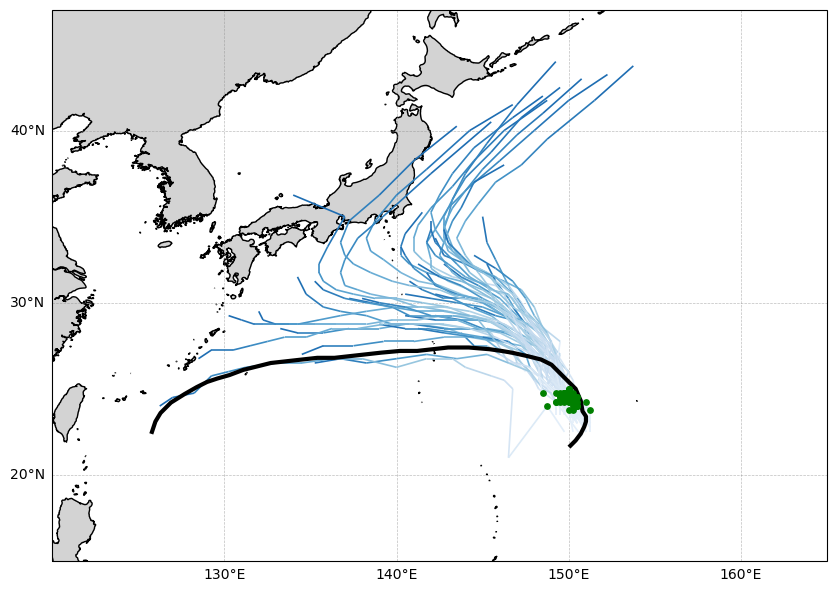

(0.0, 550.0)

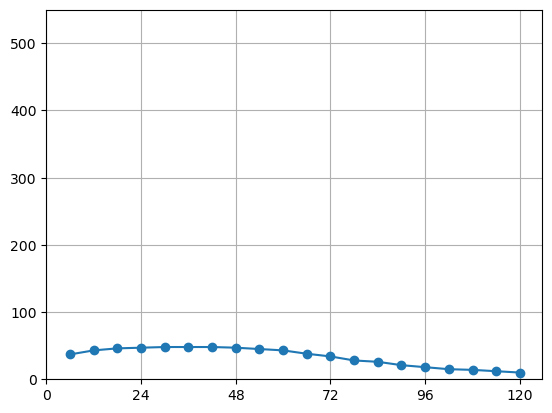

In [17]:
def plot_ens_tracks(lons, lats, ax, cmap, zorder = 0):

    x = np.array(lons)
    y = np.array(lats)

    valid_mask = ~np.isnan(x) & ~np.isnan(y)
    x_clean = x[valid_mask]
    y_clean = y[valid_mask]

    if len(x_clean) < 2:
        return

    points = np.array([x_clean, y_clean]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    t = np.linspace(0, 1, len(x_clean))

    lc = LineCollection(segments, cmap=cmap, norm=plt.Normalize(0, 1), zorder = zorder)
    lc.set_array(t)
    lc.set_linewidth(1.2)

    ax.add_collection(lc)


min_position = ssv_dict[T0]

fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})
plot_extent = [120, 165, 15, 47]
ax.set_extent(plot_extent, crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.coastlines("10m")
full_blues = plt.get_cmap('Blues')
new_colors_blue = full_blues(np.linspace(0.1, 0.8, 256))
blue_cmap = mcolors.LinearSegmentedColormap.from_list('Blues_truncated', new_colors_blue)
ax.plot(storm_lon[:41], storm_lat[:41], color='black', linestyle='-', marker='', transform=ax.projection, zorder=10, linewidth=3)

num = 0
for ens in range(MAX_MEMBERS):  
    lons = [pos['lon'] for _,pos in min_position[ens].items()]
    lats = [pos['lat'] for _,pos in min_position[ens].items()]
    plot_ens_tracks(lons, lats, ax, cmap = blue_cmap, zorder = 8)
    # max_wind = [pos['max_wind'] for _,pos in min_position[ens].items()]
    # pred_times = [pos for pos,_ in min_position[ens].items()]
    num += 1 if len(lons)>0 else 0
    # lc = colorline(ax, lons, lats, z=max_wind, cmap=plt.get_cmap('jet'), norm=mcolors.Normalize(vmin=20/1.94384, vmax=140/1.94384), linewidth=2, alpha=1, zorder = 30)

gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlocator = mticker.MultipleLocator(10)
gl.ylocator = mticker.MultipleLocator(10)

# cbar = plt.colorbar(sax, ax = ax, fraction=0.03, pad = 0.03)
# cbar.set_label('Maximum Wind Speed (knots)', fontsize=12)


ens_spread_dict = {}
ens_error_dict = {}
ens_num_dict = {}

mid_pos = []
for t in range(0, 121, 6):
    snap_time = T0 + timedelta(hours = t)
    tar_pos = []
    for ens, single_data in min_position.items():
        snap_data = min_position[ens].get(T0+timedelta(hours=t), None)

        if snap_data:
            tar_pos.append([snap_data['lon'], snap_data['lat']])
            if t == 12:
                mid_pos.append([snap_data['lon'], snap_data['lat']])

    if len(tar_pos) <= 1:
        continue
    else:
        tar_pos = np.array(tar_pos)

    snap_lon, snap_lat = storm_lon[storm_time == snap_time], storm_lat[storm_time == snap_time]
    
    # ax.text(snap_lon, snap_lat, t, zorder = 13, horizontalalignment='center', verticalalignment='center' )

    corr_pos_tar = np.copy(tar_pos)
    corr_pos_tar[:, 0] = (tar_pos[:, 0]-np.mean(tar_pos[:, 0])) * np.cos(np.radians(tar_pos[:, 1]))  # 경도에 cos(위도)를 곱해 거리 왜곡 보정
    pca_tar = PCA(n_components=1)
    pca_tar.fit(corr_pos_tar)
    pca_tar.mean_[0] = pca_tar.mean_[0] / np.cos(np.radians(pca_tar.mean_[1])) + np.mean(tar_pos[:, 0])
    projection = pca_tar.transform(corr_pos_tar)[:, 0]  # 주축에 투영된 데이터 (1차원)
    distances_tar = (projection - np.mean(projection)) * 111
    ens_spread_dict[t] = np.std(distances_tar, ddof = 1).round(1)
    # ens_error_dict[t] = haversine_distance(snap_lon, snap_lat, avg_lon, avg_lat).round(1)
    ens_num_dict[t] = len(distances_tar)

print(ens_spread_dict)
# print(ens_error_dict)
print(ens_num_dict)

ax.scatter(np.array(mid_pos)[:,0], np.array(mid_pos)[:,1], color = 'green', zorder = 12, s=15)

print(f"{num}/{MAX_MEMBERS} ensembles predicted the track.")
plt.show()

plt.plot(ens_num_dict.keys(), list(ens_num_dict.values()), marker='o')
plt.grid()
plt.xticks(range(0, 121, 24))
plt.ylim(0,550)